In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


# Análisis de Datos de Arritmias Cardíacas

## 1. Carga de Datos y Nombres de Columnas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Se carga el conjunto de datos desde la URL proporcionada.

In [3]:
data = 'data/arrhythmia.data'
df = pd.read_csv(data, header=None)

Se agregan los nombres de las columnas de acuerdo al archivo `arrythmia.names`. La primera inspección muestra las primeras 5 filas del dataset con las columnas genéricas.

In [4]:
# Primeros 15 atributos
columns = [
    "Age",
    "Sex",
    "Height",
    "Weight",
    "QRS_duration",
    "PR_interval",
    "QT_interval",
    "T_interval",
    "P_interval",
    "QRS_vector_angle",
    "T_vector_angle",
    "P_vector_angle",
    "QRST_vector_angle",
    "J_vector_angle",
    "Heart_rate"
]

# Canales en el orden dado por el archivo arrythmia.names
channels = ["DI", "DII", "DIII", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]

# Atributos 16...159: width/shape features
wave_features = [
    "Q_wave_width",
    "R_wave_width",
    "S_wave_width",
    "R_prime_wave_width",
    "S_prime_wave_width",
    "num_intrinsic_deflections",
    "ragged_R_wave",
    "diphasic_R_wave",
    "ragged_P_wave",
    "diphasic_P_wave",
    "ragged_T_wave",
    "diphasic_T_wave"
]

for ch in channels:
    for feat in wave_features:
        columns.append(f"{ch}_{feat}")

# Atributos 160...279: amplitude/area features
amp_features = [
    "JJ_wave_amplitude",
    "Q_wave_amplitude",
    "R_wave_amplitude",
    "S_wave_amplitude",
    "R_prime_wave_amplitude",
    "S_prime_wave_amplitude",
    "P_wave_amplitude",
    "T_wave_amplitude",
    "QRSA",
    "QRSTA"
]

for ch in channels:
    for feat in amp_features:
        columns.append(f"{ch}_{feat}")

# Class column
columns.append("Class")

# Se agregan las columnas al dataset
df.columns = columns

La tabla muestra las primeras filas con los nombres de columna correctos:

In [5]:
display(df.head())

,Age,Sex,Height,Weight,QRS_duration,PR_interval,QT_interval,T_interval,P_interval,QRS_vector_angle,...,V6_Q_wave_amplitude,V6_R_wave_amplitude,V6_S_wave_amplitude,V6_R_prime_wave_amplitude,V6_S_prime_wave_amplitude,V6_P_wave_amplitude,V6_T_wave_amplitude,V6_QRSA,V6_QRSTA,Class
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


## 2. Preparación de datos

### a) Detección y manejo de valores faltantes

Según la página [https://archive.ics.uci.edu/dataset/5/arrhythmia](https://archive.ics.uci.edu/dataset/5/arrhythmia), los valores faltantes están marcados con el símbolo `?`. Volvemos a cargar el dataset indicando que `?` debe ser tratado como `NaN`.

In [6]:
df = pd.read_csv(data, header=None, na_values='?')
df.columns = columns

Información general del DataFrame después de cargar los valores `?` como `NaN`:

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, Age to Class
dtypes: float64(125), int64(155)
memory usage: 988.9 KB


Conteo de valores faltantes por columna:

In [8]:
num_na = df.isna().sum()
print('Número de valores faltantes por columna:')
print(num_na[num_na>0])

Número de valores faltantes por columna:
T_vector_angle         8
P_vector_angle        22
QRST_vector_angle      1
J_vector_angle       376
Heart_rate             1
dtype: int64


Se seleccionan las columnas con valores faltantes para explorar su distribución y la presencia de outliers mediante boxplots. Las columnas de interés son 'T_vector_angle', 'P_vector_angle', 'QRST_vector_angle', y 'J_vector_angle'.

In [9]:
col_with_na = df[['T_vector_angle', 'P_vector_angle', 'QRST_vector_angle', 'J_vector_angle']]

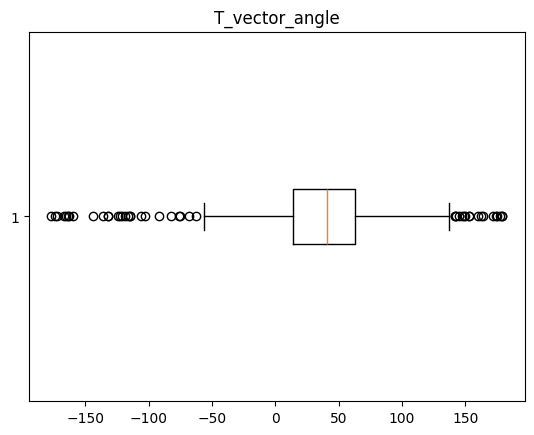

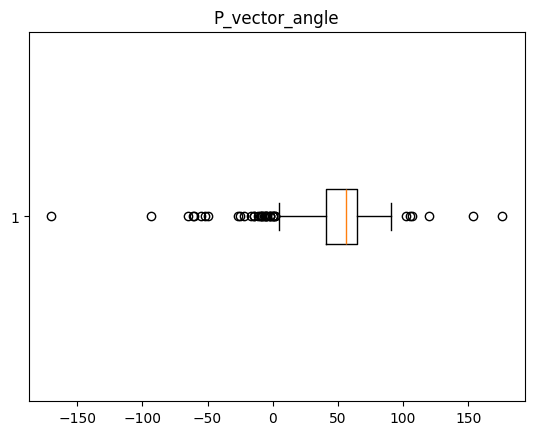

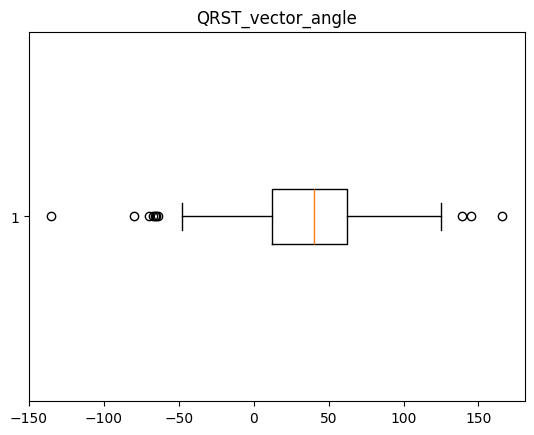

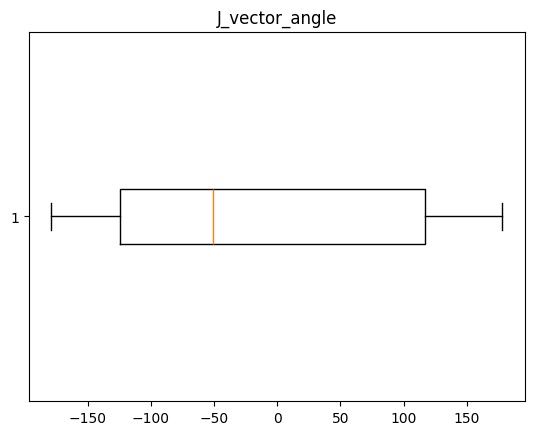

In [10]:
for col in col_with_na.columns.tolist():
  plt.boxplot(col_with_na[col].dropna(), vert=False)
  plt.title(col)
  plt.show()

Como se observa en los gráficos de arriba, 3 de las 4 características con valores faltantes contienen varios outliers. La columna **J_vector_angle** tiene 376 valores faltantes de 452 registros (83% del total), una cantidad muy alta, por lo que se decide eliminarla. Para las otras columnas, se imputarán los valores faltantes con la **mediana**, ya que es menos sensible a los outliers que la media.

In [11]:
df_cleaned = df.copy()
# Eliminar la columna 'J_vector_angle' debido al alto número de valores faltantes
df_cleaned = df_cleaned.drop(columns=['J_vector_angle'])

# Imputar los valores faltantes en las columnas restantes con la mediana
for col in ['T_vector_angle', 'P_vector_angle', 'QRST_vector_angle', 'Heart_rate']:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

print('Número de valores faltantes después de la limpieza:')
print(df_cleaned.isna().sum()[df_cleaned.isna().sum() > 0])

Número de valores faltantes después de la limpieza:
Series([], dtype: int64)


### b) Aplicar escaladores para mitigar el efecto de muestras atípicas (RobustScaler)

Se utilizará `RobustScaler` para escalar únicamente las características numéricas continuas, porque es más adecuado cuando existen muestras atípicas. Este método centra los datos usando la mediana y los escala mediante el rango intercuartílico (IQR), por lo que se ve menos afectado por valores extremos que `StandardScaler`, el cual depende de la media y la desviación estándar. Las variables binarias, indicadoras o constantes codificadas como 0/1, como `Sex` y las variables de forma de onda `ragged_*` y `diphasic_*`, se mantienen sin escalar para conservar su interpretación original. Es importante notar que `RobustScaler` no elimina las muestras atípicas, sino que mitiga su influencia durante el escalamiento.

In [12]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# Separar características (X) y la variable objetivo (y)
X = df_cleaned.drop(columns=['Class'])
y = df_cleaned['Class']

# Identificar columnas numéricas continuas y columnas binarias/indicadoras 0/1
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
binary_cols = [
    col for col in numerical_cols
    if X[col].nunique(dropna=True) <= 2 and set(X[col].dropna().unique()).issubset({0, 1})
]
continuous_cols = [col for col in numerical_cols if col not in binary_cols]

# Dividir los datos en conjuntos de entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplicar RobustScaler solo a las características numéricas continuas
scaler = RobustScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])     

print("Columnas continuas escaladas:", len(continuous_cols))
print("Columnas binarias/indicadoras conservadas sin escalar:", len(binary_cols))
print("Dimensiones de X_train después del escalado:", X_train.shape)
print("Dimensiones de X_test después del escalado:", X_test.shape)

Columnas continuas escaladas: 197
Columnas binarias/indicadoras conservadas sin escalar: 81
Dimensiones de X_train después del escalado: (361, 278)
Dimensiones de X_test después del escalado: (91, 278)


### c) Aplicar técnicas para corregir desbalanceos (sobremuestreo de la clase minoritaria)

Se aplicará `RandomOverSampler` al conjunto de entrenamiento para corregir el desequilibrio de clases. Esta técnica duplica aleatoriamente ejemplos de la clase minoritaria para equilibrar la distribución de clases. Esto se hace únicamente en el conjunto de entrenamiento para evitar el sobreajuste y la fuga de datos.

In [13]:
# Aplicar RandomOverSampler para corregir el desbalanceo de clases en el conjunto de entrenamiento
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("Conteo de clases en el conjunto de entrenamiento original:\n", y_train.value_counts())
print("\nConteo de clases en el conjunto de entrenamiento remuestreado:\n", y_train_resampled.value_counts())

Conteo de clases en el conjunto de entrenamiento original:
 Class
1     196
10     40
2      35
6      20
16     18
3      12
4      12
5      10
9       7
15      4
14      3
7       2
8       2
Name: count, dtype: int64

Conteo de clases en el conjunto de entrenamiento remuestreado:
 Class
10    196
6     196
2     196
1     196
16    196
5     196
3     196
9     196
4     196
7     196
15    196
8     196
14    196
Name: count, dtype: int64


### d) Implementar validación cruzada para evaluar cada método de selección manteniendo un conjunto de prueba separado.

La división de los datos en conjuntos de entrenamiento y prueba (80% / 20%) ya se realizó en un paso anterior. Para la validación cruzada, se usará `StratifiedKFold` para mantener la proporción de clases en cada pliegue. Esto se aplicará al conjunto de entrenamiento remuestreado para evaluar los modelos.

In [14]:
from sklearn.model_selection import StratifiedKFold

# Configurar la validación cruzada con StratifiedKFold
# n_splits define el número de pliegues (folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Se utilizará una validación cruzada con {skf.get_n_splits(X_train_resampled, y_train_resampled)} pliegues estratificados.")

Se utilizará una validación cruzada con 5 pliegues estratificados.


### Resumen de la preparación de datos

Hasta este punto, se han realizado los siguientes pasos:

1.  **Manejo de valores faltantes**: Se eliminó la columna `J_vector_angle` y se imputaron los valores faltantes de otras columnas con la mediana.
2.  **División de datos**: Los datos se dividieron en conjuntos de entrenamiento (80%) y prueba (20%) de forma estratificada.
3.  **Escalado de características**: Se aplicó `RobustScaler` solo a las características numéricas continuas de ambos conjuntos (entrenamiento y prueba), mientras que las variables binarias, indicadoras o constantes codificadas como 0/1 se conservaron sin escalar.
4.  **Corrección de desbalanceo**: Se utilizó `RandomOverSampler` en el conjunto de entrenamiento para balancear las clases.
5.  **Validación cruzada**: Se configuró `StratifiedKFold` para la evaluación de modelos en el conjunto de entrenamiento remuestreado.

## 3. Selección, entrenamiento y evaluación de modelos

Para la etapa de clasificación se utilizará `RandomForestClassifier` como modelo base. Esta decisión se debe a que Random Forest puede capturar relaciones no lineales e interacciones entre características, algo útil en un conjunto de datos con muchas variables clínicas y electrocardiográficas. Además, al combinar varios árboles de decisión, suele ser más robusto que un único modelo lineal frente a variaciones en los datos y puede ofrecer mejor desempeño en problemas tabulares de clasificación multiclase. Se fija `random_state=42` para asegurar reproducibilidad y se usa `class_weight="balanced"` como apoyo adicional ante el desbalance de clases.

### a) Búsqueda Secuencial hacia delante (SFS)

#### SFS con validación cruzada e interrupción temprana (*early stopping*) si la exactitud no mejora en 3 iteraciones.

En este apartado se implementa una búsqueda secuencial hacia delante. En cada iteración se agrega la característica que más incrementa el criterio de separabilidad de Fisher sobre el subconjunto actual. Para respetar el conjunto de prueba separado, la selección se realiza únicamente con los datos de entrenamiento y se evalúa mediante validación cruzada.

In [15]:
import time
from collections import Counter

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.decomposition import PCA

Para determinar el número de Folds revisamos cuántas ocurrencias tiene cada clase en el dataset original. Definimos el número de Folds igual al mínimo de ocurrencias de una clase. 

In [16]:
df['Class'].unique()

for class_, occurrences in df['Class'].value_counts().items():
    print(f"Clase {class_}: {occurrences} ocurrencias")

Clase 1: 245 ocurrencias
Clase 10: 50 ocurrencias
Clase 2: 44 ocurrencias
Clase 6: 25 ocurrencias
Clase 16: 22 ocurrencias
Clase 3: 15 ocurrencias
Clase 4: 15 ocurrencias
Clase 5: 13 ocurrencias
Clase 9: 9 ocurrencias
Clase 15: 5 ocurrencias
Clase 14: 4 ocurrencias
Clase 7: 3 ocurrencias
Clase 8: 2 ocurrencias


In [17]:
# Convertimos a arreglos de NumPy para facilitar los cálculos matriciales
X_train_np = X_train.to_numpy() 
X_test_np = X_test.to_numpy() 
y_train_np = y_train.to_numpy() 
y_test_np = y_test.to_numpy() 
X_train_resampled_np = X_train_resampled.to_numpy() 
X_test_resampled_reference = X_test_np  # Solo se conserva como referencia
y_train_resampled_np = y_train_resampled.to_numpy() 

# Nombres de las características ya limpiadas
feature_names = X_train.columns.tolist() 

# Clasificador base que se usará para comparar los tres métodos
modelo_base = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1)

# Ajustamos el número de folds a la clase menos frecuente para evitar errores
conteo_clases = pd.Series(y_train_np).value_counts()
min_clase = int(conteo_clases.min())

n_splits_efectivos = min_clase
cv_strategy = StratifiedKFold(n_splits=n_splits_efectivos, shuffle=True, random_state=42)

print(f"Se usarán {n_splits_efectivos} folds para la comparación de métodos.")

def oversample_fold(X_fold_train, y_fold_train):
    """Aplica sobremuestreo solo al fold de entrenamiento."""
    ros_fold = RandomOverSampler(random_state=42)
    X_bal, y_bal = ros_fold.fit_resample(X_fold_train, y_fold_train)
    return np.asarray(X_bal), np.asarray(y_bal)

def fisher_score_multivariado(X_subset, y_subset):
    """Calcula el criterio J de Fisher para un subconjunto multivariado de características."""
    clases = np.unique(y_subset)
    n_muestras, n_caracteristicas = X_subset.shape
    media_global = X_subset.mean(axis=0)

    Cw = np.zeros((n_caracteristicas, n_caracteristicas))
    Cb = np.zeros((n_caracteristicas, n_caracteristicas))

    for clase in clases:
        X_clase = X_subset[y_subset == clase]
        n_clase = len(X_clase)

        if n_clase == 0:
            continue

        proporcion = n_clase / n_muestras

        if n_clase > 1:
            cov_clase = np.cov(X_clase, rowvar=False, bias=True)
        else:
            cov_clase = np.zeros((n_caracteristicas, n_caracteristicas))

        Cw += proporcion * cov_clase

        media_clase = X_clase.mean(axis=0)
        diferencia = (media_clase - media_global).reshape(-1, 1)
        Cb += proporcion * (diferencia @ diferencia.T)

    Cw_pinv = np.linalg.pinv(Cw)
    return float(np.trace(Cw_pinv @ Cb))

def seleccion_secuencial_hacia_delante(X_data, y_data, max_features=20, paciencia=3):
    """Selecciona características de forma secuencial con interrupción temprana."""
    n_features = X_data.shape[1]
    disponibles = np.ones(n_features, dtype=bool)
    seleccionadas = []
    puntajes = []
    mejor_puntaje_global = -np.inf
    iteraciones_sin_mejora = 0

    for _ in range(min(max_features, n_features)):
        mejor_idx = None
        mejor_puntaje_local = -np.inf

        for idx in range(n_features):
            if not disponibles[idx]:
                continue

            subconjunto = seleccionadas + [idx]
            puntaje = fisher_score_multivariado(X_data[:, subconjunto], y_data)

            if puntaje > mejor_puntaje_local:
                mejor_puntaje_local = puntaje
                mejor_idx = idx

        if mejor_idx is None:
            break

        disponibles[mejor_idx] = False
        seleccionadas.append(mejor_idx)
        puntajes.append(mejor_puntaje_local)

        if mejor_puntaje_local > mejor_puntaje_global:
            mejor_puntaje_global = mejor_puntaje_local
            iteraciones_sin_mejora = 0
        else:
            iteraciones_sin_mejora += 1
            if iteraciones_sin_mejora >= paciencia:
                break

    return seleccionadas, puntajes

def resumen_metricas(y_real, y_pred):
    """Devuelve métricas de clasificación en un diccionario."""
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_real, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_real, y_pred),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

# =========================
# SFS con validación cruzada
# =========================
inicio_sfs = time.time()
sfs_resultados_cv = []

for fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train_np, y_train_np), start=1):
    X_fold_train = X_train_np[train_idx]
    y_fold_train = y_train_np[train_idx]
    X_fold_val = X_train_np[val_idx]
    y_fold_val = y_train_np[val_idx]

    # El sobremuestreo se hace solo sobre el entrenamiento del fold
    X_fold_bal, y_fold_bal = oversample_fold(X_fold_train, y_fold_train)

    seleccionadas_fold, puntajes_fold = seleccion_secuencial_hacia_delante(
        X_fold_bal, y_fold_bal, max_features=20, paciencia=3
    )

    modelo_fold = clone(modelo_base)
    modelo_fold.fit(X_fold_bal[:, seleccionadas_fold], y_fold_bal)
    y_pred_fold = modelo_fold.predict(X_fold_val[:, seleccionadas_fold])

    metricas_fold = resumen_metricas(y_fold_val, y_pred_fold)
    metricas_fold["fold"] = fold
    metricas_fold["n_caracteristicas"] = len(seleccionadas_fold)
    metricas_fold["seleccionadas"] = seleccionadas_fold
    metricas_fold["puntajes_fisher"] = puntajes_fold

    sfs_resultados_cv.append(metricas_fold)

tiempo_sfs = time.time() - inicio_sfs

# Selección final de características usando todo el conjunto de entrenamiento remuestreado
sfs_selected_final, sfs_scores_final = seleccion_secuencial_hacia_delante(
    X_train_resampled_np, y_train_resampled_np, max_features=20, paciencia=3
)

modelo_sfs_final = clone(modelo_base)
modelo_sfs_final.fit(X_train_resampled_np[:, sfs_selected_final], y_train_resampled_np)
y_pred_sfs_test = modelo_sfs_final.predict(X_test_np[:, sfs_selected_final])
metricas_sfs_test = resumen_metricas(y_test_np, y_pred_sfs_test)

print("Resumen por fold de SFS:")
display(pd.DataFrame(sfs_resultados_cv)[["fold", "n_caracteristicas", "accuracy", "precision_macro", "recall_macro", "f1_macro"]])

print("\nCaracterísticas seleccionadas en el ajuste final de SFS:")
print([feature_names[idx] for idx in sfs_selected_final])

print("\nMétricas en prueba para SFS:")
print(metricas_sfs_test)
print(f"Tiempo total de SFS: {tiempo_sfs:.2f} segundos")

Se usarán 2 folds para la comparación de métodos.
Resumen por fold de SFS:


,fold,n_caracteristicas,accuracy,precision_macro,recall_macro,f1_macro
0,1,20,0.563536,0.199250,0.196773,0.183993
1,2,20,0.572222,0.304556,0.335634,0.289132



Características seleccionadas en el ajuste final de SFS:
['V3_Q_wave_width', 'V6_R_wave_width', 'V4_QRSA', 'PR_interval', 'V3_diphasic_P_wave', 'V5_QRSA', 'DI_R_wave_width', 'Weight', 'V3_S_wave_width', 'V5_S_wave_amplitude', 'V6_P_wave_amplitude', 'V3_S_wave_amplitude', 'V3_JJ_wave_amplitude', 'V5_num_intrinsic_deflections', 'DII_R_prime_wave_width', 'AVR_R_wave_amplitude', 'V1_ragged_P_wave', 'AVR_P_wave_amplitude', 'Sex', 'V5_diphasic_T_wave']

Métricas en prueba para SFS:
{'accuracy': 0.5824175824175825, 'precision_macro': 0.24126984126984127, 'recall_macro': 0.275755857898715, 'f1_macro': 0.23233172056701468}
Tiempo total de SFS: 6.12 segundos


#### Generar gráfico exactitud por características (20 mejores características).

A continuación se visualiza cómo evoluciona el criterio de separabilidad conforme se agregan nuevas características en la selección secuencial. También se presenta la contribución incremental de cada característica seleccionada en el ajuste final.

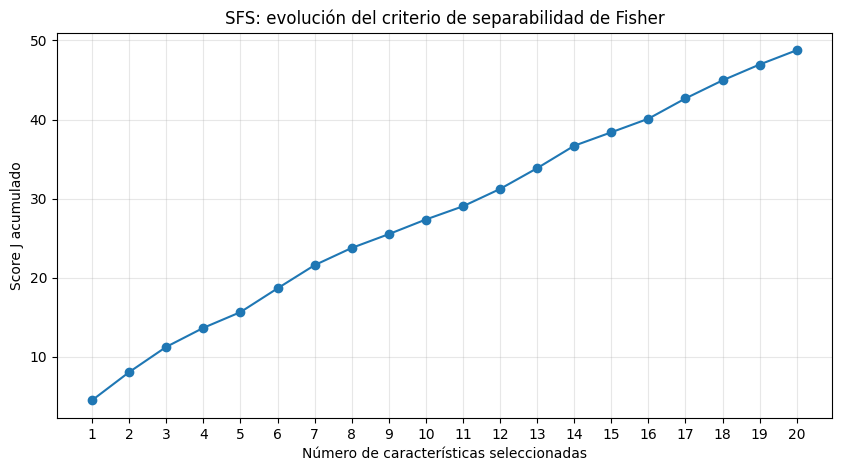

,Paso,Característica,Score_J,Incremento
0,1,V3_Q_wave_width,4.4926,4.4926
1,2,V6_R_wave_width,8.0527,3.5600
2,3,V4_QRSA,11.2438,3.1911
3,4,PR_interval,13.6483,2.4045
4,5,V3_diphasic_P_wave,15.6377,1.9894
5,6,V5_QRSA,18.6438,3.0061
6,7,DI_R_wave_width,21.5795,2.9357
7,8,Weight,23.7558,2.1763
8,9,V3_S_wave_width,25.5020,1.7462
9,10,V5_S_wave_amplitude,27.3536,1.8517


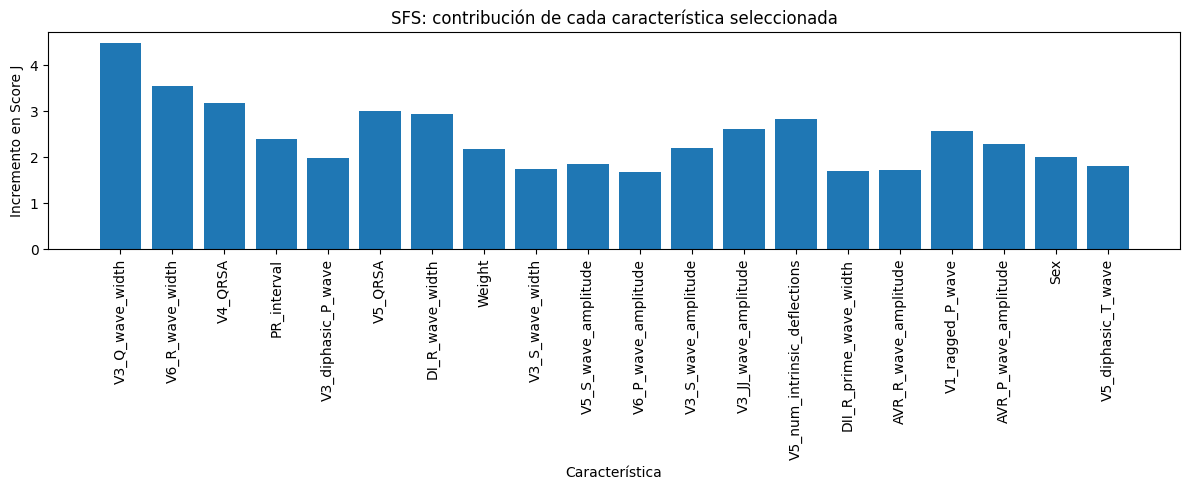

,Característica,Frecuencia_en_folds
12,AVF_num_intrinsic_deflections,2
0,DII_R_prime_wave_width,1
20,V2_ragged_P_wave,1
22,PR_interval,1
23,V5_R_wave_width,1
24,V3_S_wave_width,1
25,V2_QRSTA,1
26,V2_JJ_wave_amplitude,1
27,V5_num_intrinsic_deflections,1
28,V4_num_intrinsic_deflections,1


In [18]:
# Gráfico del criterio de Fisher acumulado durante SFS

pasos_sfs = list(range(1, len(sfs_scores_final) + 1))

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(sfs_scores_final) + 1), sfs_scores_final, marker="o")
plt.title("SFS: evolución del criterio de separabilidad de Fisher")
plt.xlabel("Número de características seleccionadas")
plt.ylabel("Score J acumulado")
plt.xticks(pasos_sfs)
plt.grid(True, alpha=0.3)
plt.show()

# Tabla de detalle de las características seleccionadas por SFS
incrementos_sfs = [sfs_scores_final[0]]
for i in range(1, len(sfs_scores_final)):
    incrementos_sfs.append(sfs_scores_final[i] - sfs_scores_final[i - 1])

df_sfs_detalle = pd.DataFrame({
    "Paso": range(1, len(sfs_selected_final) + 1),
    "Característica": [feature_names[idx] for idx in sfs_selected_final],
    "Score_J": np.round(sfs_scores_final, 4),
    "Incremento": np.round(incrementos_sfs, 4)
})
display(df_sfs_detalle)

# Gráfico de contribución individual
plt.figure(figsize=(12, 5))
plt.bar(df_sfs_detalle["Característica"], df_sfs_detalle["Incremento"])
plt.title("SFS: contribución de cada característica seleccionada")
plt.xlabel("Característica")
plt.ylabel("Incremento en Score J")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Frecuencia de aparición de características en los folds
conteo_sfs = Counter()
for resultado in sfs_resultados_cv:
    conteo_sfs.update(resultado["seleccionadas"])

df_frecuencia_sfs = pd.DataFrame({
    "Característica": [feature_names[idx] for idx in conteo_sfs.keys()],
    "Frecuencia_en_folds": list(conteo_sfs.values())
}).sort_values("Frecuencia_en_folds", ascending=False)

display(df_frecuencia_sfs.head(20))

### b) Fisher

En este método se calcula un puntaje de relevancia individual para cada característica. A diferencia de SFS, aquí cada variable se evalúa por separado y después se seleccionan las 20 que obtienen el mayor valor del criterio de Fisher.

#### Implementar función del cálculo Score de separabilidad entre clases.

In [19]:
def fisher_score_univariado(X_data, y_data):
    """Calcula el puntaje de Fisher de cada característica de manera individual."""
    clases = np.unique(y_data)
    n_muestras, n_features = X_data.shape
    media_global = X_data.mean(axis=0)
    scores = np.zeros(n_features)

    for feature_idx in range(n_features):
        dispersion_intra = 0.0
        dispersion_inter = 0.0

        for clase in clases:
            X_clase = X_data[y_data == clase, feature_idx]
            n_clase = len(X_clase)

            if n_clase == 0:
                continue

            proporcion = n_clase / n_muestras
            dispersion_intra += proporcion * np.var(X_clase)
            dispersion_inter += proporcion * (X_clase.mean() - media_global[feature_idx]) ** 2

        if dispersion_intra == 0:
            scores[feature_idx] = 0.0
        else:
            scores[feature_idx] = dispersion_inter / dispersion_intra

    return scores

# Ejemplo de cálculo sobre el entrenamiento remuestreado completo
fisher_scores_completos = fisher_score_univariado(X_train_resampled_np, y_train_resampled_np)
print("Se calcularon los puntajes de Fisher para todas las características.")
print(f"Total de características evaluadas: {len(fisher_scores_completos)}")

Se calcularon los puntajes de Fisher para todas las características.
Total de características evaluadas: 278


#### Calcular puntuaciones de relevancia de cada característica.

In [20]:
df_fisher_scores = pd.DataFrame({
    "Característica": feature_names,
    "Score_Fisher": fisher_scores_completos
}).sort_values("Score_Fisher", ascending=False)

display(df_fisher_scores.head(20))

,Característica,Score_Fisher
110,V3_Q_wave_width,4.492632
15,DI_R_wave_width,3.256490
147,V6_R_wave_width,3.135865
112,V3_S_wave_width,2.911174
228,V2_JJ_wave_amplitude,2.751032
236,V2_QRSA,2.318911
5,PR_interval,2.170666
119,V3_diphasic_P_wave,1.780716
106,V2_ragged_P_wave,1.707321
239,V3_Q_wave_amplitude,1.651963


#### Selecciona las 20 características con mayor puntuación.

Resumen por fold de Fisher:


,fold,n_caracteristicas,accuracy,precision_macro,recall_macro,f1_macro
0,1,20,0.607735,0.413058,0.386874,0.390769
1,2,20,0.611111,0.431612,0.310507,0.334084



Top 20 final de Fisher:
['V3_Q_wave_width', 'DI_R_wave_width', 'V6_R_wave_width', 'V3_S_wave_width', 'V2_JJ_wave_amplitude', 'V2_QRSA', 'PR_interval', 'V3_diphasic_P_wave', 'V2_ragged_P_wave', 'V3_Q_wave_amplitude', 'P_interval', 'QRS_duration', 'V1_QRSA', 'Heart_rate', 'QT_interval', 'V6_num_intrinsic_deflections', 'V3_JJ_wave_amplitude', 'V5_R_wave_width', 'DI_num_intrinsic_deflections', 'V3_R_wave_width']

Métricas en prueba para Fisher:
{'accuracy': 0.6153846153846154, 'precision_macro': 0.2478174603174603, 'recall_macro': 0.31156462585034017, 'f1_macro': 0.26442577030812325}
Tiempo total de Fisher: 0.71 segundos


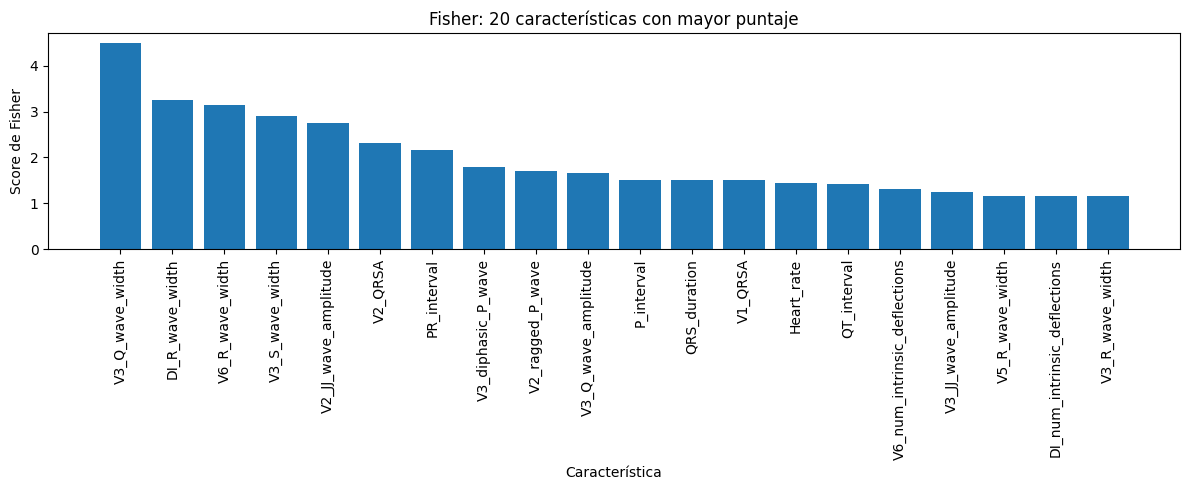

In [21]:
inicio_fisher = time.time()
fisher_resultados_cv = []

for fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train_np, y_train_np), start=1):
    X_fold_train = X_train_np[train_idx]
    y_fold_train = y_train_np[train_idx]
    X_fold_val = X_train_np[val_idx]
    y_fold_val = y_train_np[val_idx]

    X_fold_bal, y_fold_bal = oversample_fold(X_fold_train, y_fold_train)

    scores_fold = fisher_score_univariado(X_fold_bal, y_fold_bal)
    top_20_fold = np.argsort(scores_fold)[::-1][:20]

    modelo_fold = clone(modelo_base)
    modelo_fold.fit(X_fold_bal[:, top_20_fold], y_fold_bal)
    y_pred_fold = modelo_fold.predict(X_fold_val[:, top_20_fold])

    metricas_fold = resumen_metricas(y_fold_val, y_pred_fold)
    metricas_fold["fold"] = fold
    metricas_fold["n_caracteristicas"] = len(top_20_fold)
    metricas_fold["seleccionadas"] = top_20_fold.tolist()

    fisher_resultados_cv.append(metricas_fold)

tiempo_fisher = time.time() - inicio_fisher

# Selección final con el conjunto completo de entrenamiento remuestreado
fisher_top20_final = np.argsort(fisher_scores_completos)[::-1][:20]

modelo_fisher_final = clone(modelo_base)
modelo_fisher_final.fit(X_train_resampled_np[:, fisher_top20_final], y_train_resampled_np)
y_pred_fisher_test = modelo_fisher_final.predict(X_test_np[:, fisher_top20_final])
metricas_fisher_test = resumen_metricas(y_test_np, y_pred_fisher_test)

print("Resumen por fold de Fisher:")
display(pd.DataFrame(fisher_resultados_cv)[["fold", "n_caracteristicas", "accuracy", "precision_macro", "recall_macro", "f1_macro"]])

print("\nTop 20 final de Fisher:")
print([feature_names[idx] for idx in fisher_top20_final])

print("\nMétricas en prueba para Fisher:")
print(metricas_fisher_test)
print(f"Tiempo total de Fisher: {tiempo_fisher:.2f} segundos")

# Visualización de las 20 características con mayor puntaje
df_fisher_top20 = df_fisher_scores.head(20)

plt.figure(figsize=(12, 5))
plt.bar(df_fisher_top20["Característica"], df_fisher_top20["Score_Fisher"])
plt.title("Fisher: 20 características con mayor puntaje")
plt.xlabel("Característica")
plt.ylabel("Score de Fisher")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### c) PCA

En este caso no se seleccionan variables individuales, sino que se construyen nuevas variables llamadas componentes principales. Antes de aplicar PCA, se eliminan pares de características altamente correlacionadas para reducir redundancia.

#### Remover pares de características altamente correlacionadas (coeficiente > 0.9).

In [22]:
def remover_correlacion_alta(X_data, threshold=0.9):
    """Elimina columnas redundantes con correlación absoluta mayor al umbral."""
    corr_matrix = np.corrcoef(X_data, rowvar=False)
    corr_matrix = np.nan_to_num(corr_matrix)
    corr_abs = np.abs(corr_matrix)

    columnas_a_remover = set()
    n_features = corr_abs.shape[0]

    for i in range(n_features):
        for j in range(i + 1, n_features):
            if corr_abs[i, j] > threshold:
                columnas_a_remover.add(j)

    columnas_a_conservar = [idx for idx in range(n_features) if idx not in columnas_a_remover]
    return columnas_a_conservar, sorted(columnas_a_remover)

columnas_keep_pca, columnas_remove_pca = remover_correlacion_alta(X_train_resampled_np, threshold=0.9)

print(f"Características originales: {X_train_resampled_np.shape[1]}")
print(f"Características removidas por alta correlación: {len(columnas_remove_pca)}")
print(f"Características conservadas para PCA: {len(columnas_keep_pca)}")

Características originales: 278
Características removidas por alta correlación: 31
Características conservadas para PCA: 247


/Users/pm/Documents/02_UNIVERSIDAD/6TH_SEMESTER/01_RECONOCIMIENTO DE PATRONES/01_PRACTICAS/P3/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/pm/Documents/02_UNIVERSIDAD/6TH_SEMESTER/01_RECONOCIMIENTO DE PATRONES/01_PRACTICAS/P3/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


#### Determinar componentes para 95% de varianza.

/Users/pm/Documents/02_UNIVERSIDAD/6TH_SEMESTER/01_RECONOCIMIENTO DE PATRONES/01_PRACTICAS/P3/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/pm/Documents/02_UNIVERSIDAD/6TH_SEMESTER/01_RECONOCIMIENTO DE PATRONES/01_PRACTICAS/P3/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/pm/Documents/02_UNIVERSIDAD/6TH_SEMESTER/01_RECONOCIMIENTO DE PATRONES/01_PRACTICAS/P3/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/pm/Documents/02_UNIVERSIDAD/6TH_SEMESTER/01_RECONOCIMIENTO DE PATRONES/01_PRACTICAS/P3/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Resumen por fold de PCA:


,fold,n_componentes,varianza_acumulada_final,accuracy,precision_macro,recall_macro,f1_macro
0,1,12,0.954438,0.574586,0.247527,0.248980,0.244372
1,2,13,0.955027,0.533333,0.330254,0.193745,0.221112



Métricas en prueba para PCA:
{'accuracy': 0.5934065934065934, 'precision_macro': 0.2672413793103448, 'recall_macro': 0.3419501133786848, 'f1_macro': 0.292420433222204}
Componentes finales para explicar al menos 95% de la varianza: 14
Tiempo total de PCA: 0.66 segundos


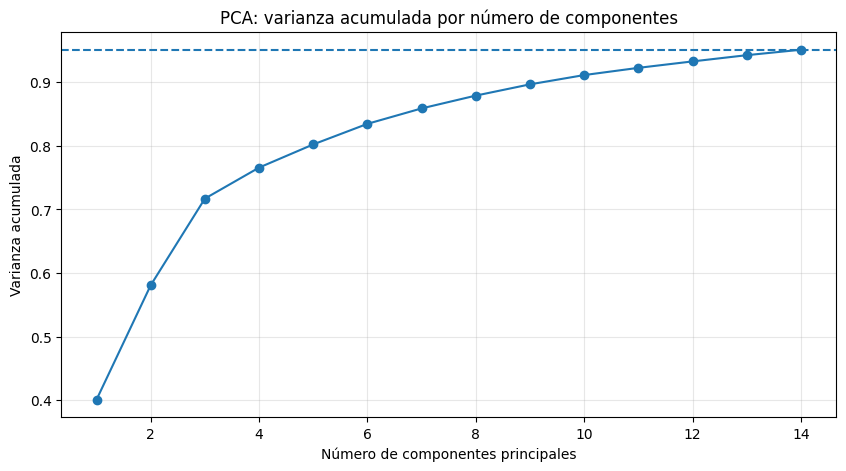

In [23]:
inicio_pca = time.time()
pca_resultados_cv = []

for fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train_np, y_train_np), start=1):
    X_fold_train = X_train_np[train_idx]
    y_fold_train = y_train_np[train_idx]
    X_fold_val = X_train_np[val_idx]
    y_fold_val = y_train_np[val_idx]

    X_fold_bal, y_fold_bal = oversample_fold(X_fold_train, y_fold_train)

    columnas_keep_fold, _ = remover_correlacion_alta(X_fold_bal, threshold=0.9)
    X_fold_bal_filtrado = X_fold_bal[:, columnas_keep_fold]
    X_fold_val_filtrado = X_fold_val[:, columnas_keep_fold]

    pca_fold = PCA(n_components=0.95, svd_solver="full", random_state=42)
    X_fold_bal_pca = pca_fold.fit_transform(X_fold_bal_filtrado)
    X_fold_val_pca = pca_fold.transform(X_fold_val_filtrado)

    modelo_fold = clone(modelo_base)
    modelo_fold.fit(X_fold_bal_pca, y_fold_bal)
    y_pred_fold = modelo_fold.predict(X_fold_val_pca)

    metricas_fold = resumen_metricas(y_fold_val, y_pred_fold)
    metricas_fold["fold"] = fold
    metricas_fold["n_componentes"] = X_fold_bal_pca.shape[1]
    metricas_fold["varianza_acumulada_final"] = pca_fold.explained_variance_ratio_.sum()

    pca_resultados_cv.append(metricas_fold)

tiempo_pca = time.time() - inicio_pca

# Ajuste final de PCA con todo el entrenamiento remuestreado
X_train_pca_filtrado = X_train_resampled_np[:, columnas_keep_pca]
X_test_pca_filtrado = X_test_np[:, columnas_keep_pca]

pca_final = PCA(n_components=0.95, svd_solver="full", random_state=42)
X_train_pca_final = pca_final.fit_transform(X_train_pca_filtrado)
X_test_pca_final = pca_final.transform(X_test_pca_filtrado)

modelo_pca_final = clone(modelo_base)
modelo_pca_final.fit(X_train_pca_final, y_train_resampled_np)
y_pred_pca_test = modelo_pca_final.predict(X_test_pca_final)
metricas_pca_test = resumen_metricas(y_test_np, y_pred_pca_test)

print("Resumen por fold de PCA:")
display(pd.DataFrame(pca_resultados_cv)[["fold", "n_componentes", "varianza_acumulada_final", "accuracy", "precision_macro", "recall_macro", "f1_macro"]])

print("\nMétricas en prueba para PCA:")
print(metricas_pca_test)
print(f"Componentes finales para explicar al menos 95% de la varianza: {X_train_pca_final.shape[1]}")
print(f"Tiempo total de PCA: {tiempo_pca:.2f} segundos")

# Gráfico de varianza acumulada
varianza_acumulada = np.cumsum(pca_final.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
plt.axhline(0.95, linestyle="--")
plt.title("PCA: varianza acumulada por número de componentes")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza acumulada")
plt.grid(True, alpha=0.3)
plt.show()

#### Visualizar proyección 2D.

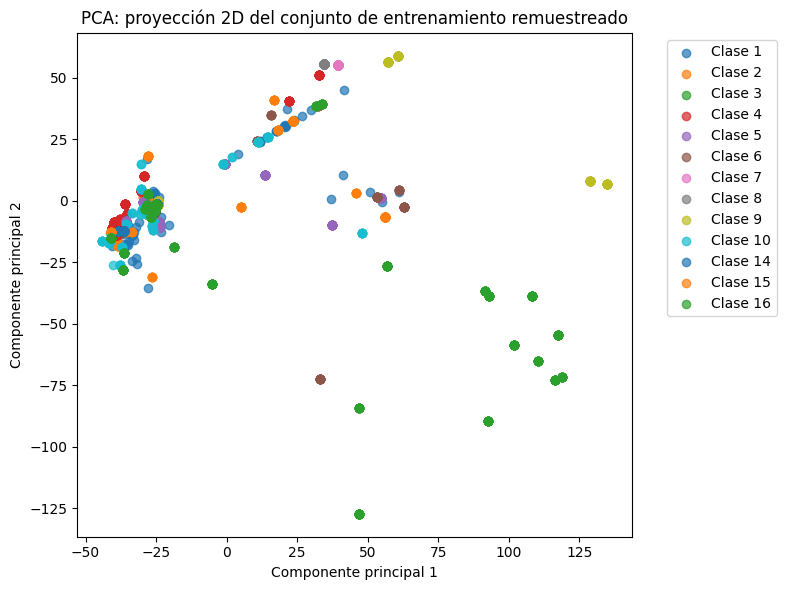

In [24]:
# Proyección de las dos primeras componentes principales
plt.figure(figsize=(8, 6))
clases_unicas = np.unique(y_train_resampled_np)

for clase in clases_unicas:
    mascara = y_train_resampled_np == clase
    plt.scatter(
        X_train_pca_final[mascara, 0],
        X_train_pca_final[mascara, 1],
        label=f"Clase {clase}",
        alpha=0.7
    )

plt.title("PCA: proyección 2D del conjunto de entrenamiento remuestreado")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

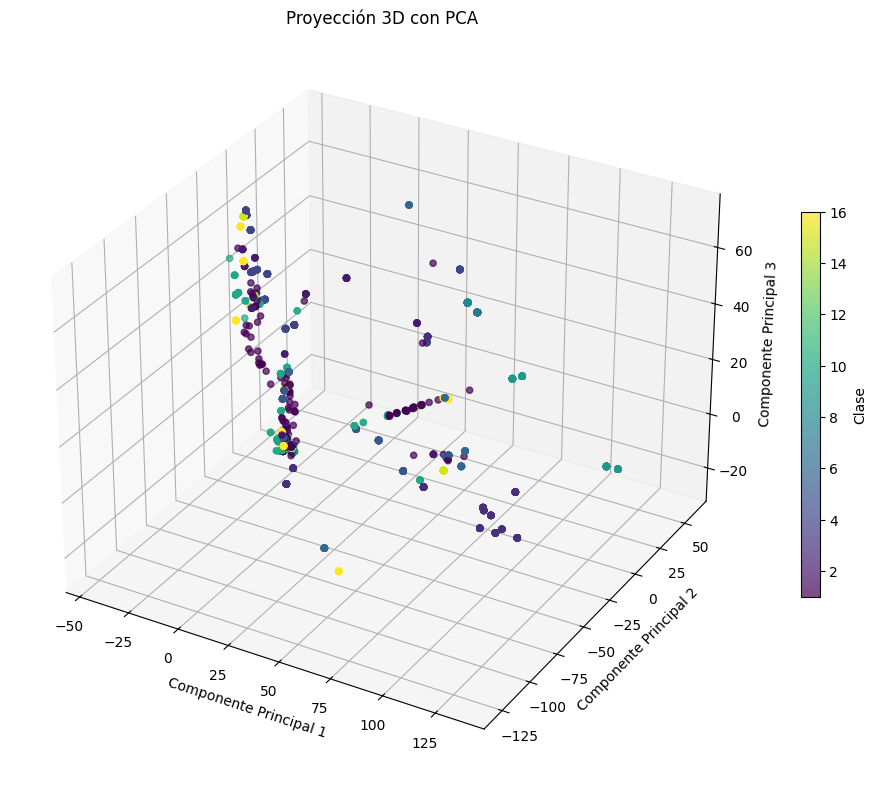

In [25]:
# Visualizar proyección 3D
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_train_pca_filtrado)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y_train_resampled_np, cmap='viridis', alpha=0.7)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.set_title('Proyección 3D con PCA')
fig.colorbar(scatter, ax=ax, label='Clase', shrink=0.5)
plt.show()

## 4. Análisis comparativo

### a) Crea una tabla comparativa con:

La siguiente tabla reúne, para cada método, el número de variables o componentes utilizados, el desempeño promedio en validación cruzada y el resultado final sobre el conjunto de prueba separado.

In [26]:
# Consolidación de resultados en una sola tabla
tabla_comparativa = pd.DataFrame([
    {
        "Método": "SFS",
        "Variables_o_componentes": len(sfs_selected_final),
        "Accuracy_CV_promedio": np.mean([r["accuracy"] for r in sfs_resultados_cv]),
        "Accuracy_CV_std": np.std([r["accuracy"] for r in sfs_resultados_cv]),
        "Accuracy_prueba": metricas_sfs_test["accuracy"],
        "Precision_macro_prueba": metricas_sfs_test["precision_macro"],
        "Recall_macro_prueba": metricas_sfs_test["recall_macro"],
        "F1_macro_prueba": metricas_sfs_test["f1_macro"],
        "Tiempo_segundos": tiempo_sfs
    },
    {
        "Método": "Fisher",
        "Variables_o_componentes": len(fisher_top20_final),
        "Accuracy_CV_promedio": np.mean([r["accuracy"] for r in fisher_resultados_cv]),
        "Accuracy_CV_std": np.std([r["accuracy"] for r in fisher_resultados_cv]),
        "Accuracy_prueba": metricas_fisher_test["accuracy"],
        "Precision_macro_prueba": metricas_fisher_test["precision_macro"],
        "Recall_macro_prueba": metricas_fisher_test["recall_macro"],
        "F1_macro_prueba": metricas_fisher_test["f1_macro"],
        "Tiempo_segundos": tiempo_fisher
    },
    {
        "Método": "PCA",
        "Variables_o_componentes": X_train_pca_final.shape[1],
        "Accuracy_CV_promedio": np.mean([r["accuracy"] for r in pca_resultados_cv]),
        "Accuracy_CV_std": np.std([r["accuracy"] for r in pca_resultados_cv]),
        "Accuracy_prueba": metricas_pca_test["accuracy"],
        "Precision_macro_prueba": metricas_pca_test["precision_macro"],
        "Recall_macro_prueba": metricas_pca_test["recall_macro"],
        "F1_macro_prueba": metricas_pca_test["f1_macro"],
        "Tiempo_segundos": tiempo_pca
    }
])

tabla_comparativa = tabla_comparativa.sort_values("Accuracy_prueba", ascending=False).reset_index(drop=True)
display(tabla_comparativa.round(4))

,Método,Variables_o_componentes,Accuracy_CV_promedio,Accuracy_CV_std,Accuracy_prueba,Precision_macro_prueba,Recall_macro_prueba,F1_macro_prueba,Tiempo_segundos
0,Fisher,20,0.6094,0.0017,0.6154,0.2478,0.3116,0.2644,0.7126
1,PCA,14,0.5540,0.0206,0.5934,0.2672,0.3420,0.2924,0.6592
2,SFS,20,0.5679,0.0043,0.5824,0.2413,0.2758,0.2323,6.1248
